# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Regression Model Evaluation

In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)

In [3]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [4]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [5]:
from sklearn.model_selection import train_test_split

# Separate predictors (X) and target (y)
X = data.drop('MEDV', axis=1)
y = data['MEDV']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [6]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## 3. Calculate and print R-squared for both the training and the testing set.

In [7]:
from sklearn.metrics import r2_score

# Calculate R-squared for both sets
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R-squared (Training): {r2_train:.4f}")
print(f"R-squared (Testing):  {r2_test:.4f}")

R-squared (Training): 0.7509
R-squared (Testing):  0.6688


## 4. Calculate and print mean squared error for both the training and the testing set.

In [8]:
from sklearn.metrics import mean_squared_error

# Calculate MSE for both sets
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"Mean Squared Error (Training): {mse_train:.4f}")
print(f"Mean Squared Error (Testing):  {mse_test:.4f}")

Mean Squared Error (Training): 21.6414
Mean Squared Error (Testing):  24.2911


## 5. Calculate and print mean absolute error for both the training and the testing set.

In [9]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE for both sets
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Mean Absolute Error (Training): {mae_train:.4f}")

Mean Absolute Error (Training): 3.3148


## Classification Model Evaluation

In [10]:
from sklearn.datasets import load_iris
data = load_iris()

In [11]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [12]:
column_names = data.feature_names

In [13]:
column_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [14]:
df = pd.DataFrame(data['data'],columns=column_names)

In [15]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [16]:
target = pd.DataFrame(data.target)

In [17]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [18]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [19]:
from sklearn.model_selection import train_test_split

# Features are in df, target is in the target variable
X = df
y = target

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [20]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train.values.ravel())

# Generate predictions
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

## 8. Calculate and print the accuracy score for both the training and the testing set.

In [21]:
from sklearn.metrics import accuracy_score

print(f"Accuracy (Train): {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Accuracy (Test):  {accuracy_score(y_test, y_test_pred):.4f}")

Accuracy (Train): 0.9750
Accuracy (Test):  0.9667


## 9. Calculate and print the balanced accuracy score for both the training and the testing set.

In [22]:
from sklearn.metrics import balanced_accuracy_score

print(f"Balanced Accuracy (Train): {balanced_accuracy_score(y_train, y_train_pred):.4f}")
print(f"Balanced Accuracy (Test):  {balanced_accuracy_score(y_test, y_test_pred):.4f}")

Balanced Accuracy (Train): 0.9750
Balanced Accuracy (Test):  0.9667


## 10. Calculate and print the precision score for both the training and the testing set.

In [23]:
from sklearn.metrics import precision_score

print(f"Precision (Train): {precision_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"Precision (Test):  {precision_score(y_test, y_test_pred, average='weighted'):.4f}")

Precision (Train): 0.9752
Precision (Test):  0.9697


## 11. Calculate and print the recall score for both the training and the testing set.

In [24]:
from sklearn.metrics import recall_score

print(f"Recall (Train): {recall_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"Recall (Test):  {recall_score(y_test, y_test_pred, average='weighted'):.4f}")

Recall (Train): 0.9750
Recall (Test):  0.9667


## 12. Calculate and print the F1 score for both the training and the testing set.

In [25]:
from sklearn.metrics import f1_score

print(f"F1 Score (Train): {f1_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"F1 Score (Test):  {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

F1 Score (Train): 0.9750
F1 Score (Test):  0.9666


## 13. Generate confusion matrices for both the training and the testing set.

In [26]:
from sklearn.metrics import confusion_matrix

print("Confusion Matrix (Train):")
print(confusion_matrix(y_train, y_train_pred))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

Confusion Matrix (Train):
[[40  0  0]
 [ 0 38  2]
 [ 0  1 39]]

Confusion Matrix (Test):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


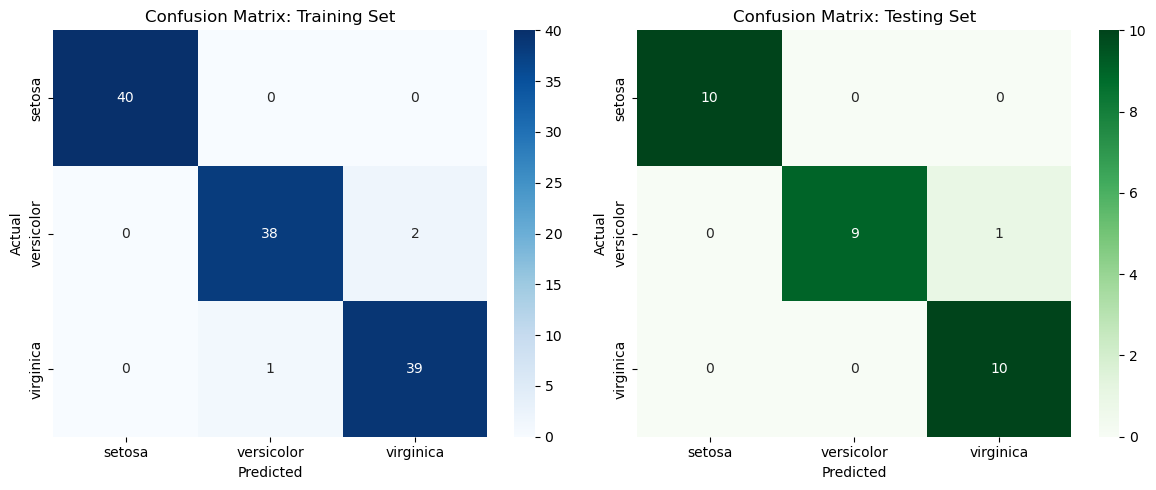

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define labels for the Iris species
labels = data.target_names

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Training Confusion Matrix
sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt='d', 
            cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax[0])
ax[0].set_title('Confusion Matrix: Training Set')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Testing Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', 
            cmap='Greens', xticklabels=labels, yticklabels=labels, ax=ax[1])
ax[1].set_title('Confusion Matrix: Testing Set')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

In [26]:
# Have fun here !